# PRAE Model Analysis

**Probabilistic Robust Autoencoder** — the PRAE augments a Transformer autoencoder with a learnable per-sample gate $\mu_i \in [0, 1]$.  
During training the gate is encouraged to shrink toward zero for samples that are hard to reconstruct (i.e. anomalous), so after training the distribution of $\mu$ directly tells us which training samples the model considers normal vs. anomalous.

**Anomaly criterion:** $\mu_i < 0.1$, as per the Lindenbaum paper.

In [ ]:
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from detection.models.transformer import BottleneckTransformer
from detection.models.prae import PRAE

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_YEAR = "2015"  # "2015" or "2017"
RESULTS_DIR = os.path.join("..", "results", TRAIN_YEAR)
print(f"Device: {DEVICE}")

## 1. Load the Trained PRAE Model

Reconstruct the architecture to match the saved checkpoint, then load the weights.

In [5]:
# Architecture parameters
NUM_FEATURES = 89
SEQ_LENGTH = 25
MODEL_DIM = 64
NUM_HEADS = 4
NUM_LAYERS = 2
REPRESENTATION_DIM = 128
PRAE_SIGMA = 0.5

# Save state dict
weights_path = os.path.join(RESULTS_DIR, "prae_weights.pth")
state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
num_train_samples = state_dict["mu"].shape[0]
print(f"Saved mu has {num_train_samples:,} entries (training samples)")

# Reconstruct model
backbone = BottleneckTransformer(
    num_features=NUM_FEATURES,
    model_dim=MODEL_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    representation_dim=REPRESENTATION_DIM,
    sequence_length=SEQ_LENGTH,
)

model = PRAE(
    backbone_model=backbone,
    num_train_samples=num_train_samples,
    lambda_reg=1.0,
    sigma=PRAE_SIGMA,
)

model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval();

Saved mu has 93,783 entries (training samples)


## 2. $\mu$ Distribution

Each training sample $i$ has a learned gate parameter $\mu_i$.  
- **$\mu_i \approx 1$** → the model can reconstruct the sample well (normal).  
- **$\mu_i \approx 0$** → the sample is hard to reconstruct and down-weighted (anomalous).

We use $\mu_i < 0.1$ as the anomaly threshold, as defined in the original paper.

mu summary statistics
Count : 93,783
Mean  : 1.0174
Std   : 0.0581
Min   : 0.6845
Max   : 1.2511
Median: 1.0189


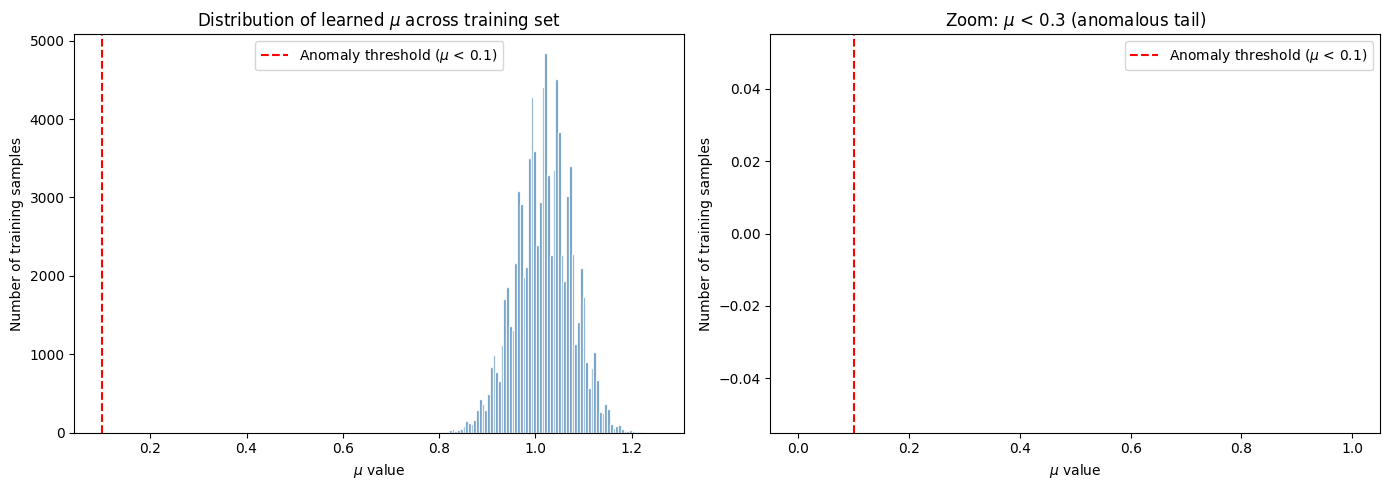

In [3]:
mu_values = model.mu.detach().cpu().numpy()

# Summary statistics
print("mu summary statistics")
print(f"Count : {len(mu_values):,}")
print(f"Mean  : {mu_values.mean():.4f}")
print(f"Std   : {mu_values.std():.4f}")
print(f"Min   : {mu_values.min():.4f}")
print(f"Max   : {mu_values.max():.4f}")
print(f"Median: {np.median(mu_values):.4f}")

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(mu_values, bins=100, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0.1, color="red", linestyle="--", linewidth=1.5, label="Anomaly threshold ($\mu$ < 0.1)")
axes[0].set_xlabel("$\mu$ value")
axes[0].set_ylabel("Number of training samples")
axes[0].set_title("Distribution of learned $\mu$ across training set")
axes[0].legend()

# Low-mu tail
low_mu = mu_values[mu_values < 0.3]
axes[1].hist(low_mu, bins=60, color="tomato", edgecolor="white", alpha=0.85)
axes[1].axvline(0.1, color="red", linestyle="--", linewidth=1.5, label="Anomaly threshold ($\mu$ < 0.1)")
axes[1].set_xlabel("$\mu$ value")
axes[1].set_ylabel("Number of training samples")
axes[1].set_title("Zoom: $\mu$ < 0.3 (anomalous tail)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Anomaly Identification ($\mu < 0.1$)

Anomaly threshold : $\mu$ < 0.1
Total training samples : 93,783
Anomalies identified  : 0
Anomaly percentage    : 0.00%
Normal percentage     : 100.00%


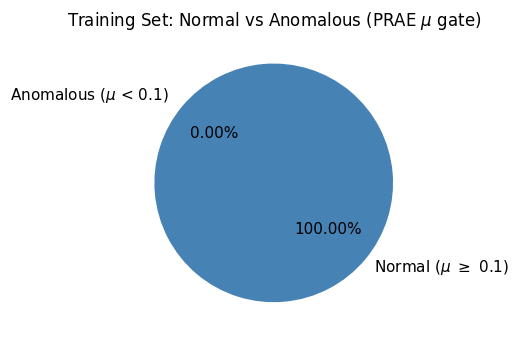

In [ ]:
ANOMALY_THRESHOLD = 0.1

anomaly_mask = mu_values < ANOMALY_THRESHOLD
n_anomalies = anomaly_mask.sum()
n_total = len(mu_values)
pct_anomalies = 100.0 * n_anomalies / n_total

print(f"Anomaly threshold : $\mu$ < {ANOMALY_THRESHOLD}")
print(f"Total training samples : {n_total:,}")
print(f"Anomalies identified  : {n_anomalies:,}")
print(f"Anomaly percentage    : {pct_anomalies:.2f}%")
print(f"Normal percentage     : {100.0 - pct_anomalies:.2f}%")

fig, ax = plt.subplots(figsize=(5, 5))
labels = [f"Normal ($\mu$ $\geq$ {ANOMALY_THRESHOLD})", f"Anomalous ($\mu$ < {ANOMALY_THRESHOLD})"]
sizes = [n_total - n_anomalies, n_anomalies]
colors = ["steelblue", "tomato"]
explode = (0, 0.05)

wedges, texts, autotexts = ax.pie(
    sizes, explode=explode, labels=labels, colors=colors,
    autopct="%1.2f%%", startangle=140, textprops={"fontsize": 11},
)
ax.set_title("Training Set: Normal vs Anomalous (PRAE $\mu$ gate)")
plt.tight_layout()
plt.show()